# Повышение качества процесса моделирования

**I. Стратегии работы с данными.**

1. Получить больше данных
2. Обработать данных
   - Очистка данных (удаление пропусков, выбросов, дубликатов).
   - Преобразование признаков (масштабирование, кодирование категориальных переменных).
   - Разделение на обучающую и тестовую выборки.
3. Сбалансировать классы
4. Придумать больше данных

**II. Стратегии работы с алгоритмами.**

1. Усложнение модели при недообучении
2. Упрощение и регуляризация модели при переобучении
3. Настройка гиперпараметров
4. Построение ансамбля моделей

В данном ноутбуке мы рассмотрим способы повышения качества моделирования через оптимизацию алгоритмов.


# Стратегии работы с алгоритмами

Настройка гиперпараметров.

Задача: получить набор гиперпараметров для максимального качества

$$
argmax_{\theta}(argmax_{w} f(\theta,w))
$$

Подходы:

1. **Ручной выбор** - на основе своей экспертной оценки вы выбираете гиперпараметры модели
2. **Поиск по сетке** - перебор всех вариантов
3. **Случайный выбор** - проверяются случайные семплы из пространства гиперпараметров
4. **Байесовская оптимизация** - применяется семплирование из пространства гиперпараметров. На основе результатов обучения модели с наборами гиперпараметров строится вероятностная функция отображения из значений гиперпараметра в целевую функцию, которая позволяет более адресно семплировать из пространства гиперпараметров в области максимума.
5. **Генетические алгоритмы** - применяются эволюционные алгоритмы с мутациями и скрещиванием

## Оценка параметров модели и кросс-валидация

Нам нужно как-то оценивать качество создаваемых нами моделей. Идея тренировать и тестировать модели на одних и тех же данных - плохая (модели будут переобучаться).

Решение этой проблемы номер 1:

- Разделять данные на 2 группы: для обучения и тестирования

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

#from jupyterthemes import jtplot
#jtplot.style()

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

Сделаем 20 разных train_test_split и обучим на них KNN-классификатор. Оценим качество на тестовой выборке.

In [3]:
import numpy as np
from sklearn.metrics import accuracy_score

n_splits = 20
random_states = np.random.randint(0, 10000, size=n_splits)
accuracies = []

for i, rs in enumerate(random_states, 1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=rs, stratify=y
    )
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Разделение {i:2d}: random_state={rs:5d}, точность={acc:.3f}")

mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)
min_acc = np.min(accuracies)
max_acc = np.max(accuracies)

print("\nИтоговая статистика по 20 разбиениям:")
print(f"Средняя точность: {mean_acc:.3f}")
print(f"Стандартное отклонение: {std_acc:.3f}")
print(f"Минимальная точность: {min_acc:.3f}")
print(f"Максимальная точность: {max_acc:.3f}")

Разделение  1: random_state=  250, точность=0.956
Разделение  2: random_state= 8480, точность=0.978
Разделение  3: random_state= 2718, точность=0.978
Разделение  4: random_state= 3292, точность=1.000
Разделение  5: random_state= 6931, точность=1.000
Разделение  6: random_state= 2841, точность=0.956
Разделение  7: random_state= 9194, точность=0.956
Разделение  8: random_state= 2894, точность=0.956
Разделение  9: random_state= 5086, точность=0.978
Разделение 10: random_state= 3708, точность=0.978
Разделение 11: random_state= 2446, точность=0.956
Разделение 12: random_state= 3641, точность=0.978
Разделение 13: random_state= 4808, точность=0.933
Разделение 14: random_state= 1110, точность=1.000
Разделение 15: random_state= 1132, точность=0.956
Разделение 16: random_state= 8628, точность=0.933
Разделение 17: random_state= 3188, точность=0.956
Разделение 18: random_state= 5138, точность=0.978
Разделение 19: random_state= 1849, точность=0.933
Разделение 20: random_state= 2060, точность=0.956


**Проблема** - качество модели имеет высокую дисперсию (high variance), поскольку примеры и в тестовой и в обучающей выборке могут значимо повлиять на полученную оценку.

**Решение** - разобьем нашу выборку на несколько групп. Одну используем для теста, на остальных обучаем. После чего меняем группу для теста и повторяем.

Усредняем полученное качество на каждой из выборок для оценки итогового качества модели.



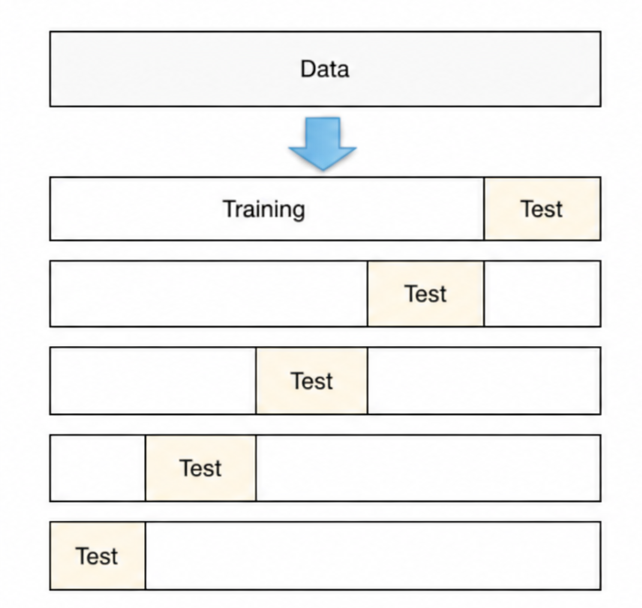

Сделаем cross_val_score для KNN.

In [4]:
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier(n_neighbors=5)

cv_scores = cross_val_score(knn, X, y, cv=5)

print("Оценки по фолдам:", cv_scores)
print(f"Средняя точность: {cv_scores.mean():.3f}")
print(f"Стандартное отклонение: {cv_scores.std():.3f}")

Оценки по фолдам: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Средняя точность: 0.973
Стандартное отклонение: 0.025


Подберем оптимальное количество соседей на основе cross_val_score.

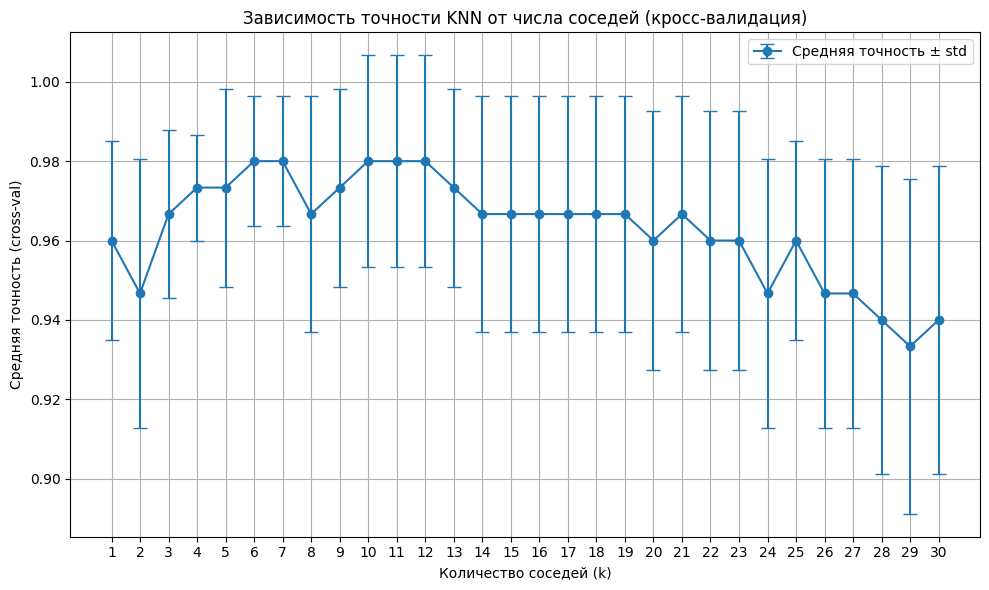

Оптимальное количество соседей: k = 6
Средняя точность при k = 6: 0.980


In [5]:
# Диапазон количества соседей
k_values = list(range(1, 31))
cv = 5
mean_scores = []
std_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=cv)
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

# Поиск оптимального k
best_k = k_values[np.argmax(mean_scores)]
best_score = max(mean_scores)

# Визуализация
plt.figure(figsize=(10, 6))
plt.errorbar(k_values, mean_scores, yerr=std_scores, fmt='-o', capsize=5, label='Средняя точность ± std')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Средняя точность (cross-val)')
plt.title('Зависимость точности KNN от числа соседей (кросс-валидация)')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Оптимальное количество соседей: k = {best_k}")
print(f"Средняя точность при k = {best_k}: {best_score:.3f}")

## 2. GridSearchCV

В некотором смысле - эта функция более продвинутая версия цикла for, описанного выше.

In [6]:
from sklearn.model_selection import GridSearchCV

In [7]:
# определим значения параметров для поиска
k_range = list(range(1, 31))
print(k_range)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [8]:
# создадим сетку параметров
param_grid = dict(n_neighbors=k_range)
param_grid = {'n_neighbors': k_range}
print(param_grid)

{'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]}


In [9]:
# зададим сетку параметров
grid = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')

Полученный объект будет перебирать параметр "количество соседей" у KNN, делать кросс-валидацию и оценивать качество, используя accuracy в качестве метрики. n_jobs=-1 заставляет параллелить вычисления по всем ядрам вашего компьютера

In [10]:
# заполним сетку данными
grid.fit(X, y)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(n_neighbors=30),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='accuracy')

In [11]:
# посмотрим на результаты
for k in grid.cv_results_:
    print(k, ":", grid.cv_results_[k][0])

mean_fit_time : 0.0011897802352905274
std_fit_time : 0.00035609251177908435
mean_score_time : 0.002856588363647461
std_score_time : 0.0005786137678167202
param_n_neighbors : 1
params : {'n_neighbors': 1}
split0_test_score : 1.0
split1_test_score : 0.9333333333333333
split2_test_score : 1.0
split3_test_score : 0.9333333333333333
split4_test_score : 0.8666666666666667
split5_test_score : 1.0
split6_test_score : 0.8666666666666667
split7_test_score : 1.0
split8_test_score : 1.0
split9_test_score : 1.0
mean_test_score : 0.96
std_test_score : 0.05333333333333332
rank_test_score : 24


In [12]:
# создадим лист со средними значениями
test_scores = grid.cv_results_['mean_test_score']
print(test_scores)

[0.96       0.95333333 0.96666667 0.96666667 0.96666667 0.96666667
 0.96666667 0.96666667 0.97333333 0.96666667 0.96666667 0.97333333
 0.98       0.97333333 0.97333333 0.97333333 0.97333333 0.98
 0.97333333 0.98       0.96666667 0.96666667 0.97333333 0.96
 0.96666667 0.96       0.96666667 0.95333333 0.95333333 0.95333333]


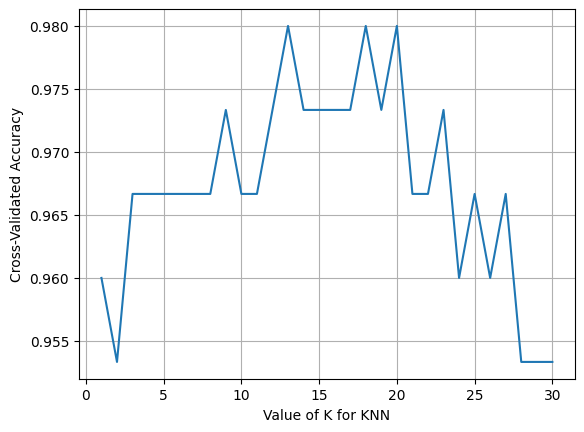

In [13]:
# выведем результаты на график
plt.plot(k_range, test_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.grid()

In [14]:
# найдем лучшую модель

print(grid.best_score_)

print(grid.best_params_)

print(grid.best_estimator_)

0.9800000000000001
{'n_neighbors': 13}
KNeighborsClassifier(n_neighbors=13)


In [15]:
from sklearn.metrics import confusion_matrix
pred = grid.best_estimator_.predict(X)
c_m = confusion_matrix(y, pred)
c_m

array([[50,  0,  0],
       [ 0, 48,  2],
       [ 0,  1, 49]])

Переберем несколько параметров одновременно: параметры k (количество соседей) и weight (тип весов) одновременно

## 3. RandomizedSearch

**GridSearch** просто перебирает все параметры. Он, конечно, найдет их самое оптимальное значение, но вопрос во времени.

Итоговое количество комбинаций для GridSearchCV - $N_1 * N_2 * N_3 * ... * N_k$, где $N_i$ - количество возможных значений i-го параметра

**RandomizedSearchCV** - выбирает случайные значения из параметров и пробует запускать обучение с ними. Можно попробовать "пристреляться" к оптимальным значениям, а затем запустить GridSearch для уточнения.

Переберем параметры k (количество соседей) и weight (количество весов) одновременно при помощи RandomizedSearchCV и сравним работу с GridSearch.

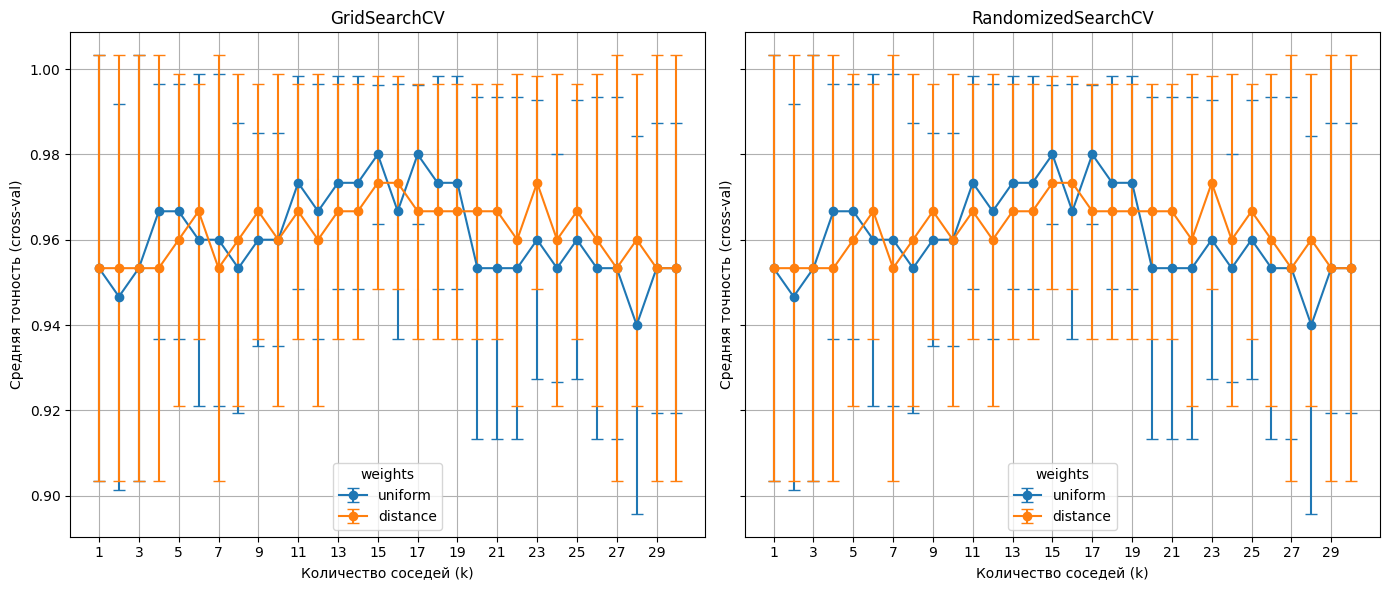

GridSearchCV — лучшее: 0.980 при {'n_neighbors': 15, 'weights': 'uniform'}, время: 7.214 с
RandomizedSearchCV — лучшее: 0.980 при {'weights': 'uniform', 'n_neighbors': 15}, время: 1.477 с


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
import time

# Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target

# Параметры для поиска
param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance']
}

# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
start_time = time.time()
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, n_jobs=-1)
grid_search.fit(X, y)
grid_time = time.time() - start_time
grid_best_score = grid_search.best_score_
grid_best_params = grid_search.best_params_
grid_cv_results = grid_search.cv_results_

# RandomizedSearchCV (полный перебор по сетке для честного сравнения)
start_time = time.time()
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=param_grid,
                                   n_iter=len(param_grid['n_neighbors']) * len(param_grid['weights']),
                                   cv=cv, n_jobs=-1, random_state=42)
random_search.fit(X, y)
rand_time = time.time() - start_time
rand_best_score = random_search.best_score_
rand_best_params = random_search.best_params_
rand_cv_results = random_search.cv_results_

# Визуализация результатов GridSearch
grid_mean = []
grid_std = []
for w in param_grid['weights']:
    scores = []
    stds = []
    for k in param_grid['n_neighbors']:
        mask = (grid_cv_results['param_n_neighbors'] == k) & (grid_cv_results['param_weights'] == w)
        idx = np.where(mask)[0][0]
        scores.append(grid_cv_results['mean_test_score'][idx])
        stds.append(grid_cv_results['std_test_score'][idx])
    grid_mean.append(scores)
    grid_std.append(stds)

# Визуализация результатов RandomizedSearch (должны совпасть с GridSearch)
rand_mean = []
rand_std = []
for w in param_grid['weights']:
    scores = []
    stds = []
    for k in param_grid['n_neighbors']:
        mask = (rand_cv_results['param_n_neighbors'] == k) & (rand_cv_results['param_weights'] == w)
        idx = np.where(mask)[0][0]
        scores.append(rand_cv_results['mean_test_score'][idx])
        stds.append(rand_cv_results['std_test_score'][idx])
    rand_mean.append(scores)
    rand_std.append(stds)

# Графики
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for i, w in enumerate(param_grid['weights']):
    axs[0].errorbar(param_grid['n_neighbors'], grid_mean[i], yerr=grid_std[i], fmt='-o', label=w, capsize=4)
    axs[1].errorbar(param_grid['n_neighbors'], rand_mean[i], yerr=rand_std[i], fmt='-o', label=w, capsize=4)

for ax in axs:
    ax.set_xlabel('Количество соседей (k)')
    ax.set_ylabel('Средняя точность (cross-val)')
    ax.set_xticks(param_grid['n_neighbors'][::2])
    ax.grid(True)
    ax.legend(title='weights')

axs[0].set_title('GridSearchCV')
axs[1].set_title('RandomizedSearchCV')
plt.tight_layout()
plt.show()

print(f"GridSearchCV — лучшее: {grid_best_score:.3f} при {grid_best_params}, время: {grid_time:.3f} с")
print(f"RandomizedSearchCV — лучшее: {rand_best_score:.3f} при {rand_best_params}, время: {rand_time:.3f} с")

## 4. Байесовская Оптимизация

Байесовская оптимизация основана на теореме Байеса

$$
P(A|X) = \frac{P(X|A)P(A)}{P(X)}
$$

$$
\propto P(X|A)P(A).
$$

Значения гиперпараметров в текущей итерации выбираются с учётом результатов на предыдущем шаге.

Основная идея алгоритма заключается в следующем – на каждой итерации подбора находится компромисс между исследованием регионов с самыми удачными из найденных комбинаций гиперпараметров и исследованием регионов с большой неопределённостью (где могут находиться ещё более удачные комбинации).

Это позволяет во многих случаях найти лучшие значения параметров модели за меньшее количество времени.

### Байесовская Оптимизация

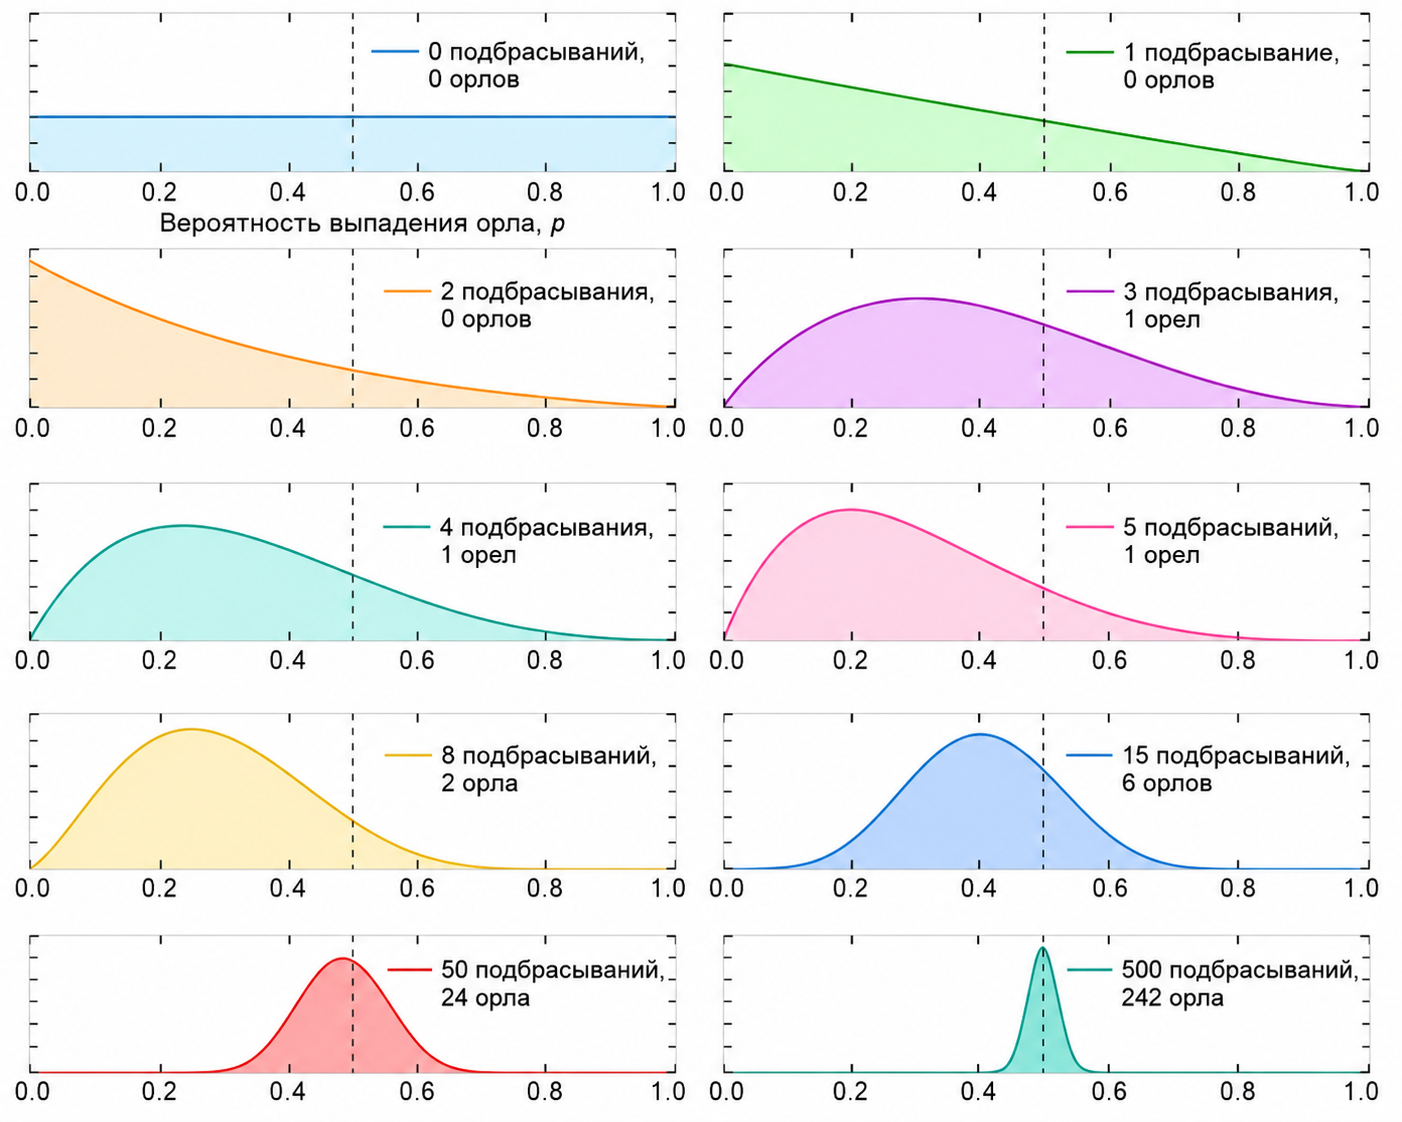

In [17]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

In [18]:
search_space = [
    hp.choice(label='n_neighbors', options=list(range(1, 30))),
    hp.choice(label='weights', options=['uniform', 'distance']),
    hp.choice(label='p', options=[1, 2, 3, 4, 5]),
]

In [19]:
from hyperopt.pyll.stochastic import sample

samples = []

# Выберем 10000 значений из последовательности
for _ in range(10):
    print(sample(search_space))

(18, 'distance', 2)
(2, 'distance', 2)
(17, 'distance', 5)
(18, 'uniform', 2)
(1, 'uniform', 5)
(25, 'uniform', 2)
(20, 'distance', 4)
(20, 'uniform', 1)
(22, 'uniform', 3)
(22, 'distance', 3)


In [20]:
def objective(params):
    knn = KNeighborsClassifier(
        n_neighbors=params[0],
        weights=params[1],
        p=params[2]
    )
    scores = cross_val_score(knn, X, y, cv=10, scoring="accuracy")
    return -scores.mean()

In [21]:
from hyperopt import rand, tpe

# Создадим алгоритмы
tpe_algo = tpe.suggest
rand_algo = rand.suggest

In [22]:
from hyperopt import Trials

# Создадим два объекта для испытаний
tpe_trials = Trials()
rand_trials = Trials()

In [23]:
from hyperopt import fmin

# Прогоним 25 оценок по алгоритме TPE
tpe_best = fmin(fn=objective, space=search_space, algo=tpe_algo, trials=tpe_trials,
                max_evals=25)

100%|██████████| 25/25 [00:02<00:00,  9.14trial/s, best loss: -0.9800000000000001]


In [24]:
print(tpe_best)

{'n_neighbors': np.int64(9), 'p': np.int64(3), 'weights': np.int64(0)}


In [25]:
# Прогоним 25 оценок на одном и том же случайном алгоритме
rand_best = fmin(
    fn=objective,
    space=search_space,
    algo=rand_algo,
    trials=rand_trials,
    max_evals=25,
    rstate=np.random.default_rng(50)
)

100%|██████████| 25/25 [00:03<00:00,  6.63trial/s, best loss: -0.9800000000000001]


In [26]:
print(rand_best)

{'n_neighbors': np.int64(12), 'p': np.int64(2), 'weights': np.int64(0)}


## 5. Генетические алгоритмы. OOB Score

Напомним идею **бэггинга** - выборка с повторением элементов из обучающего множества и обучение на этой выборке.

**OOB-оценка** - это оценка, когда для каждого $x_i$, используются только те классификаторы, которые до этого не видели $x_i$ в качестве обучающего примера

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import uniform

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

classifier = RandomForestClassifier(oob_score=True, n_estimators=20, max_depth=5)

classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=20, oob_score=True)

In [29]:
print(classifier.oob_score_)
print(classifier.score(X_test, y_test))

0.9464285714285714
0.9736842105263158


OOB-score позволяет не делать отдельный validation dataset, но обычно приводит к недооценке реального качества.

In [30]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

In [31]:
models = [
    {'name':'NB',
     'model': BernoulliNB(),
     'params': {'alpha': uniform(loc=0, scale=4)}},

    {'name':'LR',
     'model': LogisticRegression(solver='liblinear', max_iter=1000),
     'params': {
         'C': [0.1, 0.2, 0.3, 0.5, 0.7, 1],
         'penalty': ['l1', 'l2']
     }},

    {'name':'R',
     'model': Ridge(),
     'params': {
         'alpha': uniform(loc=0, scale=4),
         'solver': ['svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
     }},

    {'name':'SVC',
     'model': SVC(),
     'params': {
         'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
         'gamma': ['scale', 'auto']
     }},

    {'name':'RF',
     'model': RandomForestClassifier(),
     'params': {
         'n_estimators': [10, 25, 50, 100, 150, 200],
         'criterion': ['gini', 'entropy'],
         'max_depth': [3, 5, 7, 9, 11]
     }},

    {'name':'KN',
     'model': KNeighborsClassifier(),
     'params': {
         'n_neighbors': list(range(1, 30)),
         'weights': ['uniform', 'distance'],
         'p': [1, 2, 3]
     }},

    {'name':'DT',
     'model': DecisionTreeClassifier(),
     'params': {
         'criterion': ['gini', 'entropy'],
         'max_depth': [3, 5, 7, 9, 11]
     }}
]

res = []

for v in models:
    res.append(
        (
            v['name'],
            RandomizedSearchCV(
                v['model'],
                v['params'],
                cv=10,
                n_iter=8,
                random_state=42
            ).fit(X_train, y_train)
        )
    )

In [32]:
for r in res:
    print(r[0], r[1].best_score_, r[1].best_params_)

NB 0.33939393939393936 {'alpha': np.float64(1.49816047538945)}
LR 0.9651515151515152 {'penalty': 'l1', 'C': 1}
R 0.8948168608357452 {'alpha': np.float64(1.49816047538945), 'solver': 'sag'}
SVC 0.9916666666666666 {'kernel': 'linear', 'gamma': 'scale'}
RF 0.9477272727272726 {'n_estimators': 10, 'max_depth': 5, 'criterion': 'entropy'}
KN 0.9825757575757577 {'weights': 'distance', 'p': 3, 'n_neighbors': 26}
DT 0.9295454545454547 {'max_depth': 3, 'criterion': 'entropy'}


In [33]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_valid_scaled = sc.transform(X_valid)

knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='uniform',
    p=2
)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_valid_scaled)

wrong = y_pred != y_valid

X_wrong = X_valid_scaled[wrong]
y_wrong = y_pred[wrong]
y_true_wrong = y_valid[wrong]

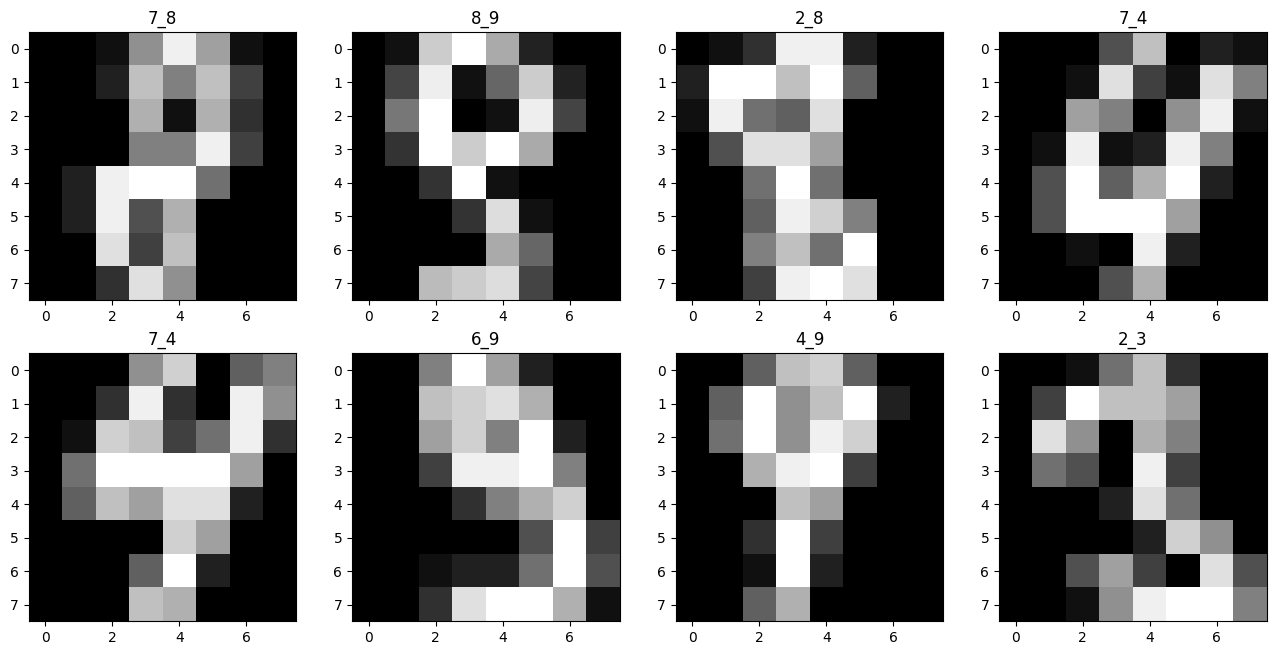

In [34]:
X_wrong = sc.inverse_transform(X_wrong)

fig = plt.figure(figsize=(16, 16))
imgs = np.random.choice(len(X_wrong), 8, replace=False)

for i in range(2):
    for j in range(4):
        img = imgs[i * 4 + j]
        plt.subplot(4, 4, i * 4 + j + 1)
        plt.imshow(X_wrong[img].reshape(8, 8), cmap='gray')
        plt.title(str(y_wrong[img]) + '_' + str(y_true_wrong[img]))

plt.show()